# Credit Risk Simulation: Sampling Error vs. Model Error

Monte Carlo simulation of a corporate bond portfolio's one-year loss distribution under a
CreditMetrics-style latent Gaussian credit-migration model, used to answer a practical question:

> When a risk desk reports a 99.9% VaR, how much of that number comes from **not having enough
> scenarios**, and how much from **assuming the wrong distribution**?

## The model

Each of the $K$ counterparties gets a standard normal creditworthiness index

$$w_i = \beta_i  y_{d(i)} + \sqrt{1-\beta_i^2}  z_i$$

where $y \sim N(0, \rho)$ are correlated **systemic** credit drivers (industry / region),
$z_i \sim N(0,1)$ are independent **idiosyncratic** shocks, and $d(i)$ maps counterparty $i$ to its
driver. The two weights are chosen so that $\mathrm{Var}(w_i) = \beta_i^2 + (1-\beta_i^2) = 1$:
$w_i$ has to stay standard normal, otherwise the thresholds below would not line up with the
migration probabilities.

Given migration probabilities $p_{i,1},\dots,p_{i,C}$ (ordered default $\to$ AAA), the thresholds
that cut the real line into credit states are

$$b_{i,c} = \Phi^{-1}\left(\sum_{j \le c} p_{i,j}\right), \qquad c = 1,\dots,C-1,$$

and the realised state of counterparty $i$ is the number of thresholds that $w_i$ exceeds. Each state
carries a known exposure; on default only the non-recovered fraction $(1-\text{recovery})$ is lost.

## The experiment

| | Scenarios | Structure | Isolates |
|---|---|---|---|
| Benchmark | 100,000 | one systemic draw per scenario | higher-precision reference distribution |
| MC1 | 5,000 | 1,000 systemic $\times$ 5 idiosyncratic | sampling error, systemic tail under-sampled |
| MC2 | 5,000 | 5,000 systemic $\times$ 1 idiosyncratic | sampling error, systemic tail well covered |
| N1 / N2 | 5,000 | normal law fitted to the MC1 / MC2 sample | combined sampling and distributional error |

Each in-sample estimator is re-run over 100 independent trials, so the tables report both the average
estimate and how much it moves from trial to trial.

The 100,000-scenario run is not the true distribution — it is a finite sample too. It is used as a
higher-precision reference because its own sampling error is roughly an order of magnitude smaller
than that of the 5,000-scenario estimators being assessed against it. Section 8 isolates the
distributional error on its own, by fitting a normal law to that same 100,000-scenario sample so that
sample size is held fixed on both sides of the comparison.

## Setup

The two CSV files need to sit next to this notebook. In Colab, drag `instrum_data.csv` and
`credit_driver_corr.csv` into the file panel on the left, or run the upload cell below.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as scs
from matplotlib.ticker import FuncFormatter
from scipy import special

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "figure.facecolor": "white"})
MILLIONS = FuncFormatter(lambda v, _: f"{v / 1e6:,.0f}M")

C = 8                      # credit states: 1 = default, ..., 8 = AAA
ALPHAS = [0.99, 0.999]     # confidence levels
N_OUT = 100_000            # benchmark scenarios
N_IN = 5_000               # in-sample scenarios per trial
N_S = 5                    # idiosyncratic draws per systemic draw in the MC1 design
N_TRIALS = 100             # independent repetitions

In [2]:
def find_data_file(name):
    """Look for a data file in the usual places (notebook folder, ./data, parent folder)."""
    for folder in [Path.cwd(), Path.cwd() / "data", Path.cwd().parent, Path.cwd().parent / "data"]:
        candidate = folder / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"{name} not found. Upload it next to this notebook "
        "(in Colab: the folder icon on the left, then the upload button)."
    )


# Uncomment in Colab if you would rather upload through a dialog:
# from google.colab import files; files.upload()

print("instruments  :", find_data_file("instrum_data.csv"))
print("correlations :", find_data_file("credit_driver_corr.csv"))

instruments  : /home/claude/latest/instrum_data.csv
correlations : /home/claude/latest/credit_driver_corr.csv


## 1. Load the portfolio

The instrument file has one row per counterparty: an id, its credit driver, beta, expected recovery
rate, market value, then $C$ migration probabilities, $C$ state exposures, and a market return.

Two things happen here that matter later. The `driver` column is **1-based** in the file, so it is
converted to a 0-based index exactly once, at the point of reading — doing this conversion in more
than one place is how the counterparties on the last driver end up silently dropped. And the default
exposure is scaled by $(1 - \text{recovery})$, because default is not a total loss.

In [3]:
def load_data():
    """Read the instrument and correlation files, returning everything the simulation needs."""
    raw = np.array(pd.read_csv(find_data_file("instrum_data.csv"), header=None))
    rho = np.array(pd.read_csv(find_data_file("credit_driver_corr.csv"), sep="\t", header=None))

    driver = raw[:, 1].astype(int) - 1        # file is 1-based, numpy is 0-based
    beta = raw[:, 2].astype(float)
    recov_rate = raw[:, 3].astype(float)
    value = raw[:, 4].astype(float)
    prob = raw[:, 5:5 + C].astype(float)
    exposure = raw[:, 5 + C:5 + 2 * C].astype(float).copy()

    # Sanity checks: a bad driver index is otherwise very hard to notice.
    assert driver.min() >= 0 and driver.max() < len(rho), "credit-driver index out of range"
    assert np.allclose(prob.sum(axis=1), 1.0), "migration probabilities do not sum to one"

    # Only the non-recovered fraction is lost on default (state index 0).
    exposure[:, 0] = (1 - recov_rate) * exposure[:, 0]

    # Credit-state boundaries: cumulative migration probability through the inverse normal CDF.
    CS_Bdry = special.ndtri(np.cumsum(prob[:, 0:C - 1], axis=1))

    # Cholesky factor of the driver correlation, for generating correlated normals.
    sqrt_rho = np.linalg.cholesky(rho)

    return driver, beta, value, prob, exposure, CS_Bdry, sqrt_rho, rho


driver, beta, value, prob, exposure, CS_Bdry, sqrt_rho, rho = load_data()

K = len(beta)              # number of counterparties
num_drivers = len(rho)     # number of credit drivers
portf_v = value.sum()      # portfolio value

print(f"Counterparties : {K}")
print(f"Credit drivers : {num_drivers}")
print(f"Credit states  : {C}")
print(f"Portfolio value: ${portf_v:,.0f}")
print(f"Beta range     : {beta.min():.2f} - {beta.max():.2f}")

ratings = ["default", "CCC", "B", "BB", "BBB", "A", "AA", "AAA"]
current_state = np.argmax(prob, axis=1)      # most likely state today
counts = pd.Series([ratings[s] for s in current_state]).value_counts()
counts.reindex([r for r in ratings if r in counts.index]).to_frame("Counterparties").T

Counterparties : 100
Credit drivers : 50
Credit states  : 8
Portfolio value: $845,973,751
Beta range     : 0.45 - 0.66


,CCC,B,BB,BBB,A,AA,AAA
Counterparties,4,5,22,38,22,6,3


## 2. Portfolio weights

Two portfolios are built from the same 100 names. **Portfolio 1** is value-weighted (one unit of each
bond, so the largest issuers dominate); **Portfolio 2** is equal-weighted in dollar terms, so it holds
more units of the cheaper bonds. `x0` converts a loss *per unit* into dollars.

In [4]:
w0 = [value / portf_v,                 # portfolio 1: value-weighted
      np.ones(K) / K]                  # portfolio 2: equal-weighted
x0 = [(portf_v / value) * w for w in w0]

pd.DataFrame({
    "Portfolio 1 (units)": x0[0],
    "Portfolio 2 (units)": x0[1],
}).describe().loc[["min", "mean", "max"]].style.format("{:,.2f}")

,Portfolio 1 (units),Portfolio 2 (units)
min,1.00,0.22
mean,1.00,3.07
max,1.00,16.93


## 3. Scenario generation

One function covers both simulation designs. `n_idiosyncratic=1` draws a fresh state of the economy
for every scenario (the MC2 design and the benchmark); `n_idiosyncratic=5` reuses each systemic draw
five times (MC1), which is cheaper but visits only a fifth as many states of the economy.

The loop runs over counterparties, one line per term of the model, so it reads like the formula. The
scenario dimension is vectorised inside the loop: `w` is an array over all scenarios rather than a
single number, and `np.searchsorted` maps the whole array to credit states at once.

In [5]:
def simulate_losses(n_scenarios, n_idiosyncratic=1, rng=None):
    """Simulate a loss matrix of shape (n_scenarios, K).

    n_idiosyncratic = 1 gives one fresh systemic draw per scenario;
    n_idiosyncratic = k reuses each systemic draw k times (the MC1 design).
    """
    rng = rng or np.random.default_rng()
    n_systemic = n_scenarios // n_idiosyncratic

    # Correlated systemic drivers: independent normals rotated by the Cholesky factor.
    y = rng.standard_normal((n_systemic, num_drivers)) @ sqrt_rho.T
    if n_idiosyncratic > 1:
        y = np.repeat(y, n_idiosyncratic, axis=0)

    z = rng.standard_normal((n_scenarios, K))     # idiosyncratic shocks
    losses = np.zeros((n_scenarios, K))

    for i in range(K):
        # Creditworthiness index for counterparty i, across all scenarios at once.
        w = beta[i] * y[:, driver[i]] + np.sqrt(1 - beta[i] ** 2) * z[:, i]

        # Which credit state did it land in? = how many boundaries it exceeded.
        state = np.searchsorted(CS_Bdry[i], w, side="right")

        losses[:, i] = exposure[i, state]

    return losses

## 4. Risk measures

`var_cvar` is the empirical pair. The CVaR formula carries a fractional correction: when $n\alpha$ is
not an integer the quantile falls *between* two order statistics. Weighting that boundary observation
by its fractional part makes the tail average use exactly $n(1-\alpha)$ observations' worth of tail
probability, rather than rounding to a whole observation. The same function is used for the
benchmark and for the in-sample trials, so any difference in the tables comes from the sampling
design and not from a change of formula.

`normal_var_cvar` is the closed form under a normal approximation. The
$\phi(\Phi^{-1}(\alpha)) / (1-\alpha)$ factor is the standard truncated-mean result for a normal.

In [6]:
def var_cvar(portfolio_losses, alpha):
    """Empirical VaR and CVaR of a 1-D array of portfolio losses."""
    losses = np.sort(portfolio_losses)
    n = len(losses)
    idx = int(math.ceil(n * alpha))

    var = losses[idx - 1]
    cvar = ((idx - n * alpha) * var + losses[idx:].sum()) / (n * (1 - alpha))
    return var, cvar


def normal_var_cvar(mu, sigma, alpha):
    """VaR and CVaR under a normal approximation of the loss distribution."""
    q = scs.norm.ppf(alpha)
    var = mu + q * sigma
    cvar = mu + sigma * scs.norm.pdf(q) / (1 - alpha)
    return var, cvar

## 5. Benchmark distribution

100,000 scenarios, used as a higher-precision reference rather than as truth. A normal approximation
is fitted to the same sample for comparison; its standard deviation comes from the **full covariance matrix** of counterparty losses,
$\sigma_p = \sqrt{x^\top \Sigma x}$, which is where the correlation between counterparties enters.

In [7]:
rng = np.random.default_rng(seed=1)
Losses_out = simulate_losses(N_OUT, n_idiosyncratic=1, rng=rng)

mu_l = Losses_out.mean(axis=0)
var_l = np.cov(Losses_out, rowvar=False)

portf_losses_out = []
VaRout = np.zeros((2, len(ALPHAS)))
CVaRout = np.zeros((2, len(ALPHAS)))
VaRinN = np.zeros((2, len(ALPHAS)))
CVaRinN = np.zeros((2, len(ALPHAS)))

for p in range(2):
    pl = Losses_out @ x0[p]
    portf_losses_out.append(pl)

    mu_p = mu_l @ x0[p]
    sigma_p = np.sqrt(x0[p] @ var_l @ x0[p])

    for q, alpha in enumerate(ALPHAS):
        VaRout[p, q], CVaRout[p, q] = var_cvar(pl, alpha)
        VaRinN[p, q], CVaRinN[p, q] = normal_var_cvar(mu_p, sigma_p, alpha)

summary = pd.DataFrame([
    {
        "Portfolio": f"Portfolio {p + 1}",
        "Mean loss": portf_losses_out[p].mean(),
        "Std. dev.": portf_losses_out[p].std(),
        "99% VaR": VaRout[p, 0],
        "99% CVaR": CVaRout[p, 0],
        "99.9% VaR": VaRout[p, 1],
        "99.9% CVaR": CVaRout[p, 1],
    }
    for p in range(2)
])
summary.style.format({col: "${:,.0f}" for col in summary.columns[1:]}).hide(axis="index")

Portfolio,Mean loss,Std. dev.,99% VaR,99% CVaR,99.9% VaR,99.9% CVaR
Portfolio 1,"$6,370,542","$8,561,924","$37,150,651","$44,954,626","$55,369,288","$62,525,423"
Portfolio 2,"$6,227,649","$6,386,885","$27,440,078","$33,685,551","$41,313,452","$47,460,017"


The mean loss is a fraction of a percent of portfolio value, but the 99.9% quantile is an order of
magnitude larger. The distribution is strongly right-skewed, because the tail is reached when a
common systemic driver moves against many counterparties at once.

## 6. In-sample trials

100 independent repetitions of the MC1 and MC2 designs. Each trial produces an empirical estimate and
a normal-approximation estimate fitted to the same sample, so MC1 pairs with N1 and MC2 with N2.

In [8]:
estimators = ["MC1", "MC2", "N1", "N2"]
VaRin = {e: np.zeros((2, len(ALPHAS), N_TRIALS)) for e in estimators}
CVaRin = {e: np.zeros((2, len(ALPHAS), N_TRIALS)) for e in estimators}

rng = np.random.default_rng(seed=2)

for tr in range(N_TRIALS):
    samples = {
        "MC1": simulate_losses(N_IN, n_idiosyncratic=N_S, rng=rng),   # 1,000 systemic x 5
        "MC2": simulate_losses(N_IN, n_idiosyncratic=1, rng=rng),     # 5,000 systemic x 1
    }
    if tr == N_TRIALS - 1:
        last_samples = samples          # kept for the plots further down

    for mc, normal in [("MC1", "N1"), ("MC2", "N2")]:
        losses = samples[mc]
        mu_l = losses.mean(axis=0)
        var_l = np.cov(losses, rowvar=False)

        for p in range(2):
            pl = losses @ x0[p]
            mu_p = mu_l @ x0[p]
            sigma_p = np.sqrt(x0[p] @ var_l @ x0[p])

            for q, alpha in enumerate(ALPHAS):
                VaRin[mc][p, q, tr], CVaRin[mc][p, q, tr] = var_cvar(pl, alpha)
                VaRin[normal][p, q, tr], CVaRin[normal][p, q, tr] = normal_var_cvar(
                    mu_p, sigma_p, alpha
                )

print(f"{N_TRIALS} trials done.")

100 trials done.


## 7. Sampling error

MC1 and MC2 use the correct model and the same number of scenarios; they differ only in how those
scenarios are spent. MC1 reuses each systemic draw five times, so it explores only 1,000 states of the
economy.

In [9]:
def error_table(estimators):
    """Mean in-sample estimate vs. benchmark, with relative error and trial-to-trial dispersion."""
    rows = []
    for p in range(2):
        for q, alpha in enumerate(ALPHAS):
            for measure, estimates, truth in [("VaR", VaRin, VaRout), ("CVaR", CVaRin, CVaRout)]:
                true_value = truth[p, q]
                for e in estimators:
                    draws = estimates[e][p, q]
                    rows.append({
                        "Portfolio": f"Portfolio {p + 1}",
                        "Measure": f"{measure} {alpha:.1%}",
                        "Estimator": e,
                        "In-sample mean": draws.mean(),
                        "Benchmark": true_value,
                        "Relative error": abs(draws.mean() - true_value) / true_value,
                        "Std. dev. across trials": draws.std(ddof=1),
                    })
    return pd.DataFrame(rows)


def show(df):
    return df.style.format({
        "In-sample mean": "${:,.0f}",
        "Benchmark": "${:,.0f}",
        "Relative error": "{:.2%}",
        "Std. dev. across trials": "${:,.0f}",
    }).hide(axis="index")


sampling = error_table(["MC1", "MC2"])
show(sampling)

Portfolio,Measure,Estimator,In-sample mean,Benchmark,Relative error,Std. dev. across trials
Portfolio 1,VaR 99.0%,MC1,"$36,853,771","$37,150,651",0.80%,"$1,230,382"
Portfolio 1,VaR 99.0%,MC2,"$37,193,106","$37,150,651",0.11%,"$1,052,625"
Portfolio 1,CVaR 99.0%,MC1,"$43,895,511","$44,954,626",2.36%,"$1,817,720"
Portfolio 1,CVaR 99.0%,MC2,"$44,690,928","$44,954,626",0.59%,"$1,458,874"
Portfolio 1,VaR 99.9%,MC1,"$52,290,822","$55,369,288",5.56%,"$3,041,894"
Portfolio 1,VaR 99.9%,MC2,"$53,851,533","$55,369,288",2.74%,"$2,976,404"
Portfolio 1,CVaR 99.9%,MC1,"$59,403,397","$62,525,423",4.99%,"$5,120,466"
Portfolio 1,CVaR 99.9%,MC2,"$61,622,193","$62,525,423",1.44%,"$4,769,584"
Portfolio 2,VaR 99.0%,MC1,"$27,108,266","$27,440,078",1.21%,"$1,243,185"
Portfolio 2,VaR 99.0%,MC2,"$27,370,910","$27,440,078",0.25%,"$777,813"


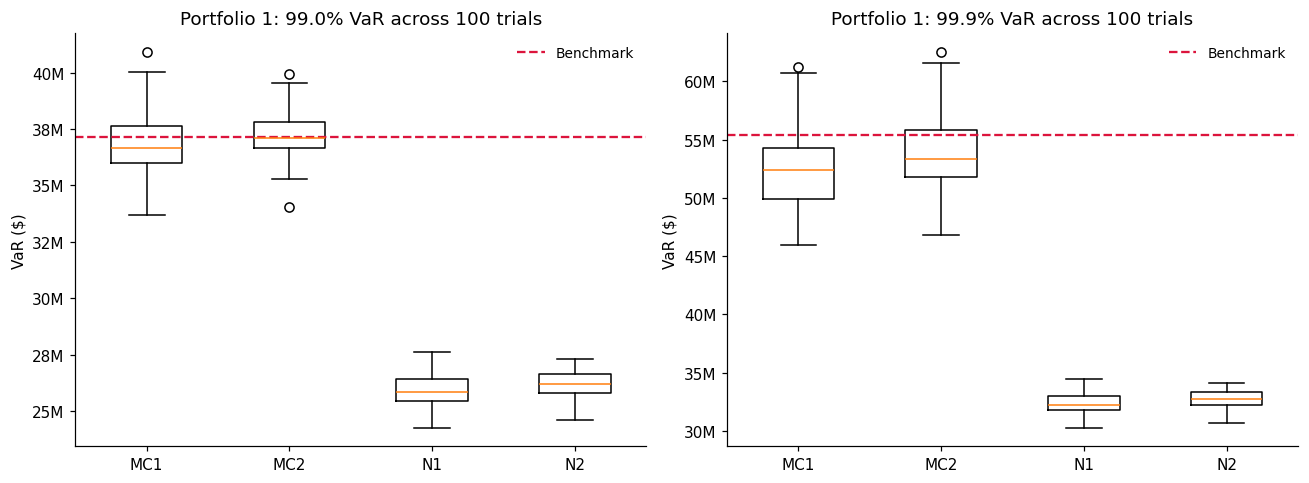

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for q, (alpha, ax) in enumerate(zip(ALPHAS, axes)):
    ax.boxplot([VaRin[e][0, q] for e in estimators], tick_labels=estimators, widths=0.5)
    ax.axhline(VaRout[0, q], color="crimson", ls="--", lw=1.5, label="Benchmark")
    ax.set_title(f"Portfolio 1: {alpha:.1%} VaR across {N_TRIALS} trials")
    ax.set_ylabel("VaR ($)")
    ax.yaxis.set_major_formatter(MILLIONS)
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

At these confidence levels CVaR is the *noisier* of the two estimates, not the steadier one. With
5,000 scenarios only five observations sit beyond the 99.9% quantile, so the tail average is driven by
a handful of extreme draws, whereas VaR reads a single order statistic from a denser part of the
sample.

In [11]:
# Relative dispersion (std / mean) across trials: is VaR or CVaR the steadier estimate?
rows = []
for mc in ["MC1", "MC2"]:
    for p in range(2):
        for q, alpha in enumerate(ALPHAS):
            rows.append({
                "Design": mc,
                "Portfolio": f"Portfolio {p + 1}",
                "Level": f"{alpha:.1%}",
                "VaR rel. dispersion": VaRin[mc][p, q].std(ddof=1) / VaRin[mc][p, q].mean(),
                "CVaR rel. dispersion": CVaRin[mc][p, q].std(ddof=1) / CVaRin[mc][p, q].mean(),
            })

dispersion = pd.DataFrame(rows)
dispersion.style.format({
    "VaR rel. dispersion": "{:.2%}",
    "CVaR rel. dispersion": "{:.2%}",
}).hide(axis="index")

Design,Portfolio,Level,VaR rel. dispersion,CVaR rel. dispersion
MC1,Portfolio 1,99.0%,3.34%,4.14%
MC1,Portfolio 1,99.9%,5.82%,8.62%
MC1,Portfolio 2,99.0%,4.59%,6.04%
MC1,Portfolio 2,99.9%,9.26%,10.77%
MC2,Portfolio 1,99.0%,2.83%,3.26%
MC2,Portfolio 1,99.9%,5.53%,7.74%
MC2,Portfolio 2,99.0%,2.84%,3.95%
MC2,Portfolio 2,99.9%,8.23%,9.26%


## 8. Model error

N1 and N2 fit a normal law to exactly the same 5,000-scenario samples that MC1 and MC2 used. Their gap
against the 100,000-scenario benchmark therefore contains *both* finite-sample error and distributional
error. Since section 7 showed the empirical sampling error to be a few percent, the much larger gap
here is driven mostly by the normal assumption — but the two effects are not formally separated yet.


In [12]:
model = error_table(["N1", "N2"])
show(model)

Portfolio,Measure,Estimator,In-sample mean,Benchmark,Relative error,Std. dev. across trials
Portfolio 1,VaR 99.0%,N1,"$25,942,991","$37,150,651",30.17%,"$727,653"
Portfolio 1,VaR 99.0%,N2,"$26,221,067","$37,150,651",29.42%,"$568,047"
Portfolio 1,CVaR 99.0%,N1,"$28,803,247","$44,954,626",35.93%,"$806,915"
Portfolio 1,CVaR 99.0%,N2,"$29,112,572","$44,954,626",35.24%,"$631,816"
Portfolio 1,VaR 99.9%,N1,"$32,390,680","$55,369,288",41.50%,"$906,537"
Portfolio 1,VaR 99.9%,N2,"$32,739,199","$55,369,288",40.87%,"$711,936"
Portfolio 1,CVaR 99.9%,N1,"$34,727,542","$62,525,423",44.46%,"$971,525"
Portfolio 1,CVaR 99.9%,N2,"$35,101,592","$62,525,423",43.86%,"$764,188"
Portfolio 2,VaR 99.0%,N1,"$20,908,319","$27,440,078",23.80%,"$586,772"
Portfolio 2,VaR 99.0%,N2,"$21,110,004","$27,440,078",23.07%,"$362,178"


In [13]:
comparison = (
    pd.concat([sampling, model])
    .groupby(["Measure", "Estimator"], as_index=False)["Relative error"].mean()
    .pivot(index="Measure", columns="Estimator", values="Relative error")
    .reindex(["VaR 99.0%", "CVaR 99.0%", "VaR 99.9%", "CVaR 99.9%"])
)
comparison.style.format("{:.1%}").background_gradient(cmap="Reds", axis=None)

Estimator,MC1,MC2,N1,N2
Measure,,,,
VaR 99.0%,1.0%,0.2%,27.0%,26.2%
CVaR 99.0%,2.4%,0.5%,33.7%,33.1%
VaR 99.9%,4.2%,1.4%,39.6%,39.0%
CVaR 99.9%,5.0%,0.9%,43.3%,42.7%


To isolate the distributional error on its own, compare the empirical VaR/CVaR of the 100,000-scenario
sample against a normal law fitted to *that same sample*. Sample size is now identical on both sides,
so whatever remains is attributable to the shape of the assumed distribution.

In [14]:
rows = []
for p in range(2):
    for q, alpha in enumerate(ALPHAS):
        for measure, emp, norm in [("VaR", VaRout, VaRinN), ("CVaR", CVaRout, CVaRinN)]:
            rows.append({
                "Portfolio": f"Portfolio {p + 1}",
                "Measure": f"{measure} {alpha:.1%}",
                "Empirical (100,000)": emp[p, q],
                "Normal fit (same sample)": norm[p, q],
                "Understatement": (emp[p, q] - norm[p, q]) / emp[p, q],
            })

pure_model_error = pd.DataFrame(rows)
pure_model_error.style.format({
    "Empirical (100,000)": "${:,.0f}",
    "Normal fit (same sample)": "${:,.0f}",
    "Understatement": "{:.1%}",
}).hide(axis="index")

Portfolio,Measure,"Empirical (100,000)",Normal fit (same sample),Understatement
Portfolio 1,VaR 99.0%,"$37,150,651","$26,288,656",29.2%
Portfolio 1,CVaR 99.0%,"$44,954,626","$29,190,018",35.1%
Portfolio 1,VaR 99.9%,"$55,369,288","$32,829,009",40.7%
Portfolio 1,CVaR 99.9%,"$62,525,423","$35,199,456",43.7%
Portfolio 2,VaR 99.0%,"$27,440,078","$21,085,840",23.2%
Portfolio 2,CVaR 99.0%,"$33,685,551","$23,250,151",31.0%
Portfolio 2,VaR 99.9%,"$41,313,452","$25,964,707",37.2%
Portfolio 2,CVaR 99.9%,"$47,460,017","$27,732,974",41.6%


## 9. Loss distributions

The red curve is a normal fitted to the sample; the vertical lines are the risk measures. A symmetric
density matched to the first two moments of a skewed sample has to put its right tail too close to the
mean — which is exactly what the model error in the table above measures.

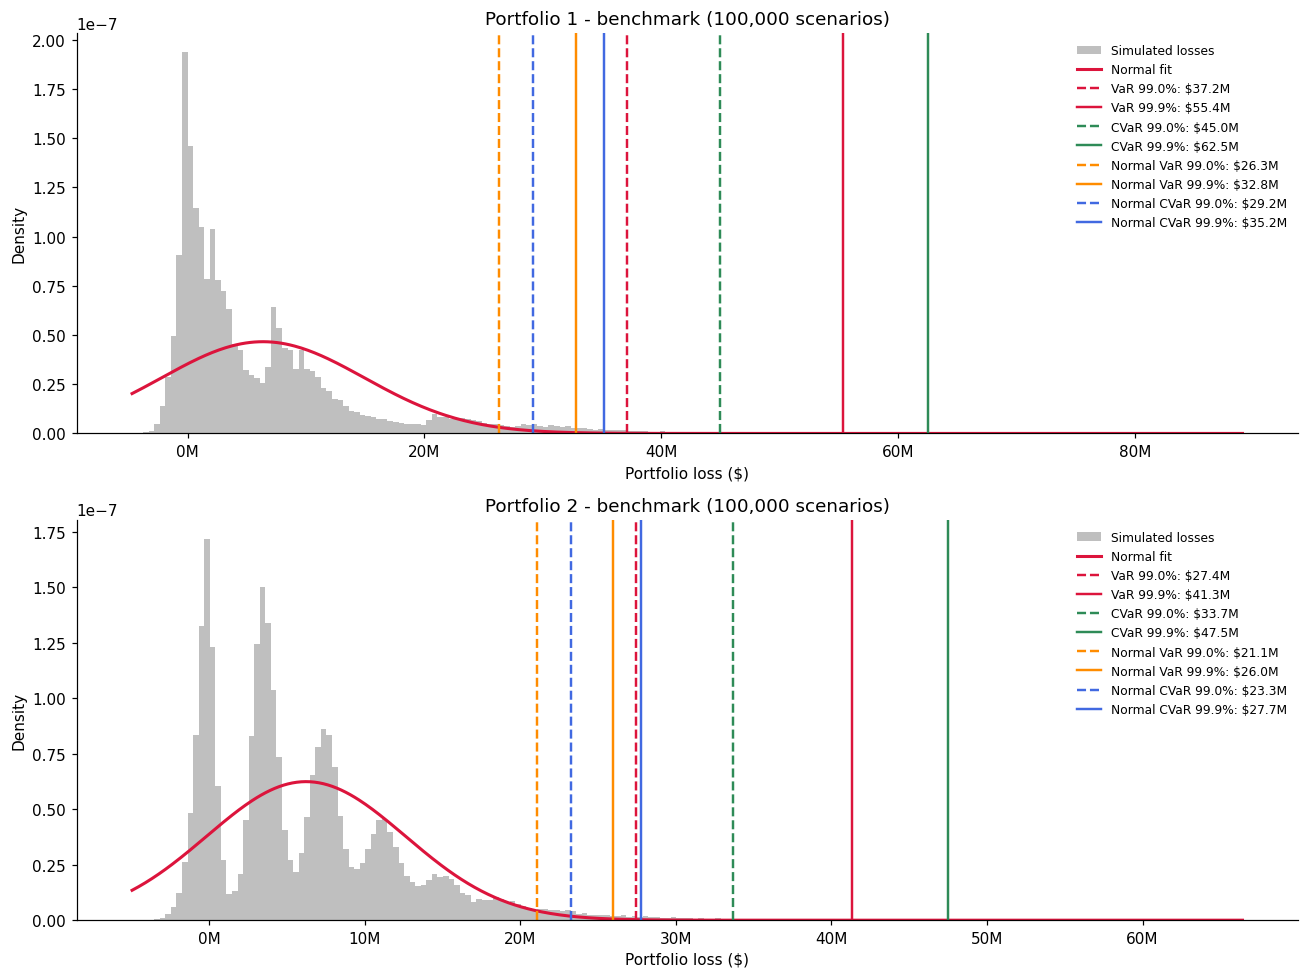

In [15]:
def plot_loss_distribution(pl, var, cvar, norm_var, norm_cvar, title, bins=200, ax=None):
    """Histogram of portfolio losses with a fitted normal and the risk measures marked."""
    ax = ax or plt.subplots(figsize=(12, 5))[1]

    ax.hist(pl, bins=bins, density=True, color="0.75", edgecolor="none", label="Simulated losses")

    mu, sigma = pl.mean(), pl.std()
    grid = np.linspace(pl.min(), pl.max(), 500)
    ax.plot(grid, np.exp(-0.5 * ((grid - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi)),
            color="crimson", lw=2, label="Normal fit")

    for values, colour, label in [(var, "crimson", "VaR"),
                                  (cvar, "seagreen", "CVaR"),
                                  (norm_var, "darkorange", "Normal VaR"),
                                  (norm_cvar, "royalblue", "Normal CVaR")]:
        for q, alpha in enumerate(ALPHAS):
            ax.axvline(values[q], color=colour, ls="--" if q == 0 else "-", lw=1.6,
                       label=f"{label} {alpha:.1%}: ${values[q] / 1e6:,.1f}M")

    ax.set_title(title)
    ax.set_xlabel("Portfolio loss ($)")
    ax.set_ylabel("Density")
    ax.xaxis.set_major_formatter(MILLIONS)
    ax.legend(loc="upper right", fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    return ax


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for p, ax in enumerate(axes):
    plot_loss_distribution(
        portf_losses_out[p],
        var=VaRout[p], cvar=CVaRout[p],
        norm_var=VaRinN[p], norm_cvar=CVaRinN[p],
        title=f"Portfolio {p + 1} - benchmark ({N_OUT:,} scenarios)",
        ax=ax,
    )
fig.tight_layout()

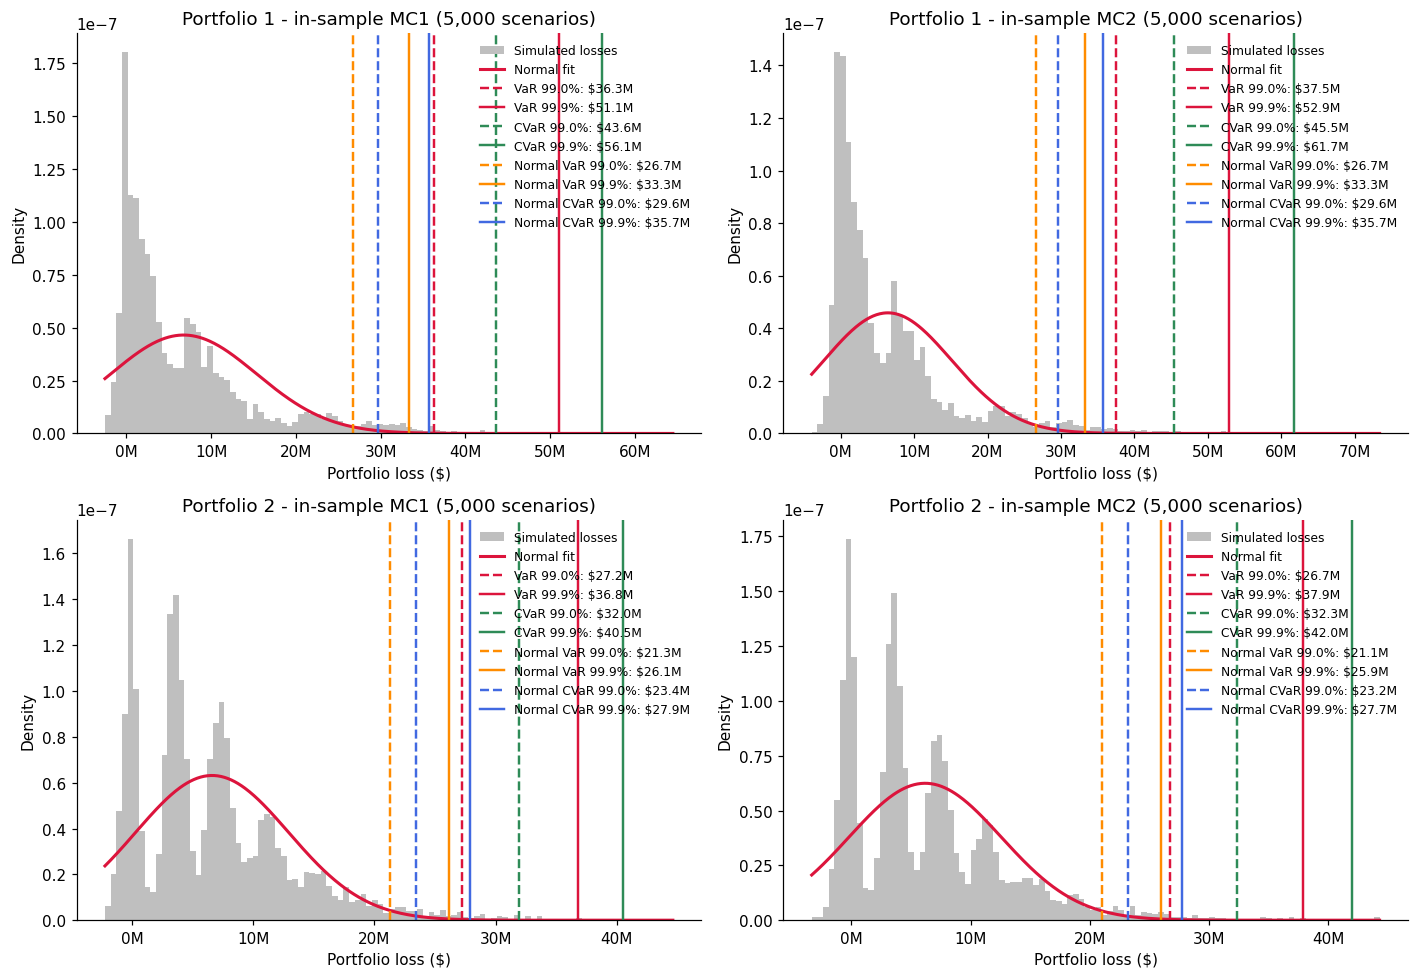

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for p in range(2):
    for j, (mc, normal) in enumerate([("MC1", "N1"), ("MC2", "N2")]):
        pl = last_samples[mc] @ x0[p]
        plot_loss_distribution(
            pl,
            var=VaRin[mc][p, :, -1], cvar=CVaRin[mc][p, :, -1],
            norm_var=VaRin[normal][p, :, -1], norm_cvar=CVaRin[normal][p, :, -1],
            title=f"Portfolio {p + 1} - in-sample {mc} ({N_IN:,} scenarios)",
            bins=100,
            ax=axes[p, j],
        )

fig.tight_layout()

## 10. Conclusions

**Sampling error is small; distributional error is not.** With 5,000 scenarios the empirical estimators
land within a few percent of the 100,000-scenario reference, while a normal law fitted to that same
100,000-scenario sample understates the 99.9% measures by roughly 40%. Adding scenarios cannot fix an
assumption that is wrong in shape: the loss distribution is right-skewed with a long tail, and no
symmetric density matched to its first two moments reaches that far out. Note also that N1 and N2 have
the *tightest* spread across trials — a confidently reported wrong number.

**Where scenarios are spent matters more than how many.** MC1 and MC2 draw the same 5,000 scenarios,
but MC1 visits only 1,000 states of the economy. Since the tail of a credit portfolio is driven by
systemic moves that hit many counterparties at once, reusing systemic draws leaves the tail thinly
sampled: MC1's trial-to-trial dispersion is wider than MC2's in all eight comparisons, and its bias is
larger at every confidence level.

**CVaR carries more information but is noisier here.** CVaR describes the severity of losses beyond the
quantile, which VaR cannot. In these repeated 5,000-scenario experiments it was nonetheless the less
stable of the two, because at 99.9% it averages only a handful of extreme observations. The two
measures answer different questions, and the choice between them is not settled by stability alone.

**Practical implications.** A normal approximation can materially understate portfolio tail risk if it
is used without validation against the empirical distribution — the gap widens as the confidence level
rises, which is precisely where capital and limit decisions are made. Given a fixed simulation budget,
allocating it to systemic draws rather than idiosyncratic ones buys more tail accuracy.

## References

- Gupton, Finger and Bhatia (1997), *CreditMetrics Technical Document*, J.P. Morgan.
- Merton (1974), "On the Pricing of Corporate Debt", *Journal of Finance* 29(2).
- Rockafellar and Uryasev (2002), "Conditional Value-at-Risk for General Loss Distributions",
  *Journal of Banking & Finance* 26(7).
